# Day 5 — Segmentation and ETL Evaluation

This notebook reviews the provided DeepLabV3+ segmentation outputs,
morphology threshold comparison, final mask selection rationale,
and AIS ETL conservation/quality results.

No synthetic data or fabricated evaluation metrics are used.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. DeepLabV3+ Model Metadata

Model: ResNet50DeepLabV3Plus

Checkpoint: `oil_spill_seg_resnet_50_deeplab_v3+_80.pt`

Input channels: 3

Classification method: pixelwise argmax with threshold

Oil class index: 1

Normalization:
- Mean: 0.5185
- Standard deviation: 0.197

Model status: experimental

In [3]:
class_counts = {
    "sea_surface": {"count": 22513572, "percentage_pct": 83.33},
    "oil_spill": {"count": 74696, "percentage_pct": 0.28},
    "look_alike": {"count": 884061, "percentage_pct": 3.27},
    "ship": {"count": 2058, "percentage_pct": 0.01},
    "land": {"count": 3543610, "percentage_pct": 13.12},
}

class_df = pd.DataFrame(class_counts).T
class_df

,count,percentage_pct
sea_surface,22513572.0,83.33
oil_spill,74696.0,0.28
look_alike,884061.0,3.27
ship,2058.0,0.01
land,3543610.0,13.12


In [4]:
probability_stats = pd.DataFrame({
    "Statistic": ["Mean", "Min", "Max"],
    "Global": [
        0.011831003241240978,
        5.739332897825022e-10,
        0.9916979074478149
    ],
    "Masked": [
        0.684205949306488,
        0.2547608017921448,
        0.9916979074478149
    ]
})

probability_stats

,Statistic,Global,Masked
0,Mean,1.183100e-02,0.684206
1,Min,5.739333e-10,0.254761
2,Max,9.916979e-01,0.991698


## 2. Morphology Threshold Comparison

Evaluated thresholds:

- 0.20
- 0.30
- 0.40
- 0.50

Final selected threshold: **0.30**

Post-processing:
`MORPH_OPEN(3x3) -> MORPH_CLOSE(5x5) -> MIN_AREA(100px)`

In [5]:
threshold_df = pd.DataFrame([
    [0.20, 253765, 118, 50196, 0.41048774123191833],
    [0.30, 159232, 77, 33645, 0.50908362865448],
    [0.40, 99757, 69, 25426, 0.6050793528556824],
    [0.50, 62853, 51, 12680, 0.7003750205039978],
], columns=[
    "Threshold",
    "Oil Pixels Retained",
    "Connected Components",
    "Largest Component Area (px)",
    "Mean Probability Inside Mask"
])

threshold_df

,Threshold,Oil Pixels Retained,Connected Components,Largest Component Area (px),Mean Probability Inside Mask
0,0.2,253765,118,50196,0.410488
1,0.3,159232,77,33645,0.509084
2,0.4,99757,69,25426,0.605079
3,0.5,62853,51,12680,0.700375


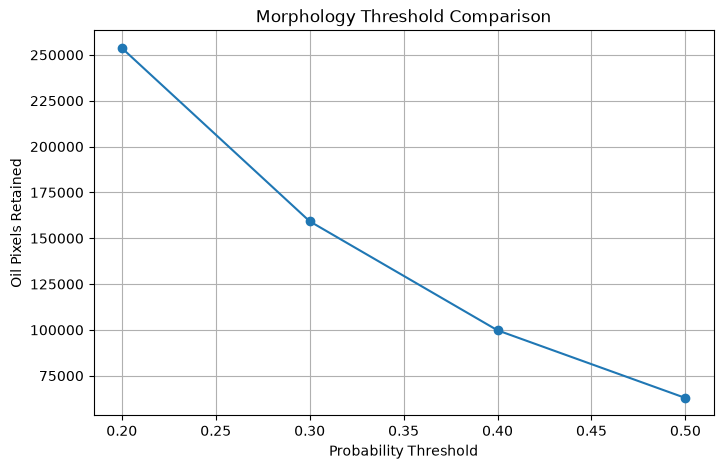

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(
    threshold_df["Threshold"],
    threshold_df["Oil Pixels Retained"],
    marker="o"
)
plt.xlabel("Probability Threshold")
plt.ylabel("Oil Pixels Retained")
plt.title("Morphology Threshold Comparison")
plt.grid(True)
plt.show()

### Final Mask Selection

**Selected threshold: 0.30**

The threshold was selected as a balance between removing isolated
low-confidence noise and false-positive look-alikes while preserving
the physical continuity of the main oil-slick components without
excessive fragmentation.

Final segmentation metadata:

- Pixel count before cleanup: 159,232
- Pixel count after cleanup: 158,334
- Number of components: 47
- Total area: 19.621 km²
- Total perimeter: 187,885.9 m

## 3. AIS ETL Conservation and Quality Validation

The ETL evaluation uses the real 10,000-row development subset:

`data/ais/ais_sample_10000.csv`

This is a development subset of the original AIS source and must not
be interpreted as complete AIS coverage.

In [7]:
etl_results = pd.DataFrame([
    ["Input rows", 10000],
    ["Valid rows before deduplication", 10000],
    ["Duplicate rows removed", 23],
    ["Cleaned output rows", 9977],
    ["Unique MMSIs", 6890],
    ["Invalid MMSIs", 0],
    ["Invalid coordinates", 0],
    ["Invalid timestamps", 0],
    ["Remaining duplicate observations", 0],
    ["Gap count", 3087],
    ["Median gap (seconds)", 71],
    ["95th-percentile gap (seconds)", 101],
    ["Maximum gap (seconds)", 67750],
    ["PostGIS rows loaded", 9977],
    ["Invalid geometries", 0],
    ["Coordinate mismatches", 0],
], columns=["Metric", "Value"])

etl_results

,Metric,Value
0,Input rows,10000
1,Valid rows before deduplication,10000
2,Duplicate rows removed,23
3,Cleaned output rows,9977
4,Unique MMSIs,6890
5,Invalid MMSIs,0
6,Invalid coordinates,0
7,Invalid timestamps,0
8,Remaining duplicate observations,0
9,Gap count,3087


In [8]:
input_rows = 10000
duplicates_removed = 23
output_rows = 9977

conservation_check = input_rows - duplicates_removed == output_rows

print("Conservation check:", conservation_check)
print(f"{input_rows} - {duplicates_removed} = {output_rows}")

Conservation check: True
10000 - 23 = 9977


## 4. Segmentation Metrics Availability

IoU, Dice, Precision and Recall require a corresponding labelled
ground-truth mask and prediction pair for the evaluation being reported.

No such final-model labelled mask/prediction pair is available in the
provided Day-5 evidence.

Therefore:

- IoU: Unavailable
- Dice: Unavailable
- Precision: Unavailable
- Recall: Unavailable

No synthetic values are reported.

The metric implementation from the earlier evaluation work remains
available, but earlier controlled/example values are not reused as
DeepLabV3+ performance.

## 5. Day 5 Conclusion

### Segmentation
- DeepLabV3+ model metadata reviewed.
- Class pixel counts and percentages reviewed.
- Global and masked oil probability statistics reviewed.
- Thresholds 0.20, 0.30, 0.40 and 0.50 compared.
- Threshold 0.30 selected based on the provided mask-selection rationale.
- Morphological cleanup parameters and final mask statistics recorded.

### AIS ETL
- Input/output conservation verified: 10,000 - 23 = 9,977.
- Duplicate removal verified.
- MMSI, coordinate and timestamp validation reviewed.
- Gap statistics reviewed.
- PostGIS load validation reviewed.

### Segmentation accuracy metrics
- IoU, Dice, Precision and Recall are unavailable for final-model
  evaluation because a corresponding labelled ground-truth mask and
  prediction pair was not provided.
- No fabricated metrics were used.